<a href="https://colab.research.google.com/github/OlhaZahrebelna/Behaviour_bank_project/blob/main/Behaviour_bank__Project_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# === Основні бібліотеки ===
import numpy as np
import pandas as pd

# === Візуалізація ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Sklearn preprocessing & pipeline ===
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

# === Data split ===
from sklearn.model_selection import train_test_split

# === Моделі ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

# === Балансування ===
from imblearn.over_sampling import SMOTE

# === Метрики ===
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score
)

# === Hyperparameter tuning ===
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# === Інтерпретація ===
import shap


import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### Основна задача
Задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit).

### Опис змінних


#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме.

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Mid-Tech project/bank-additional-full.csv', sep=';')
df.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.nunique()

,0
age,78
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5


In [6]:
print(df['month'].unique())

['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']


In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Аналіз описової статистики показує, що середній вік клієнтів становить 40 років, медіана — 38 років, а 75% клієнтів мають вік до 47 років. Це свідчить про те, що більшість клієнтів банку належать до працездатної вікової групи.
Тривалість останнього контакту (duration) має середнє значення 258 секунд, але медіана становить 180 секунд, що може свідчити про асиметричний розподіл з наявністю довгих дзвінків (максимум — 4918 секунд).
Кількість контактів у межах поточної кампанії (campaign) зазвичай невелика: медіана становить 2 контакти, а 75% клієнтів отримували не більше 3 дзвінків. Проте максимальне значення — 56 контактів, що може вказувати на викиди або агресивні повторні спроби контакту.
Змінна pdays має медіану 999, що означає, що більшість клієнтів раніше не контактувалися у попередніх кампаніях. Це підтверджує і змінна previous, де 75% значень дорівнюють 0, тобто попередніх контактів фактично не було.
Соціально-економічні показники (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) мають відносно невелику варіативність, оскільки вони є макроекономічними індикаторами, що змінюються повільніше, ніж індивідуальні характеристики клієнтів.

In [8]:
df_positive = df[df['y'] == 'yes']
df_negative = df[df['y'] == 'no']

In [9]:
df_positive.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000
mean,40.913147,553.191164,2.051724,792.035560,0.492672,-1.233448,93.354386,-39.789784,2.123135,5095.115991
std,13.837476,401.171871,1.666245,403.407181,0.860344,1.623626,0.676644,6.139668,1.742598,87.572641
min,17.000000,37.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,31.000000,253.000000,1.000000,999.000000,0.000000,-1.800000,92.893000,-46.200000,0.849000,5017.500000
50%,37.000000,449.000000,2.000000,999.000000,0.000000,-1.800000,93.200000,-40.400000,1.266000,5099.100000
75%,50.000000,741.250000,2.000000,999.000000,1.000000,-0.100000,93.918000,-36.100000,4.406000,5191.000000
max,98.000000,4199.000000,23.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.887346
yes,0.112654


Маємо суттєвий дисбаланс між класами (yes значно менше ніж no)

In [11]:
df['y_binary'] = df['y'].map({'no': 0, 'yes': 1})

In [12]:
df.corr(numeric_only=True)['y_binary'].sort_values(ascending=False)

,y_binary
y_binary,1.000000
duration,0.405274
previous,0.230181
cons.conf.idx,0.054878
age,0.030399
campaign,-0.066357
cons.price.idx,-0.136211
emp.var.rate,-0.298334
euribor3m,-0.307771
pdays,-0.324914


In [13]:
df.drop(columns=['y_binary'], inplace=True)

Кореляційний аналіз показав, що найбільший позитивний зв’язок із підписанням депозиту має змінна duration, що означає: чим довше триває розмова з клієнтом, тим більша ймовірність успішного результату. Проте ця змінна не може використовуватись у фінальній моделі, оскільки її значення відоме лише після завершення дзвінка. Також спостерігається позитивний зв’язок із змінною previous, що може свідчити про вищу ймовірність успіху серед клієнтів, з якими банк вже контактував раніше. Макроекономічні показники (euribor3m, emp.var.rate, nr.employed, pdays) демонструють негативну кореляцію з цільовою змінною.

In [14]:
categorical = df.dtypes[df.dtypes == 'object'].index

for col in categorical:
    print(f"\n{col}")
    print(df[col].value_counts())


job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

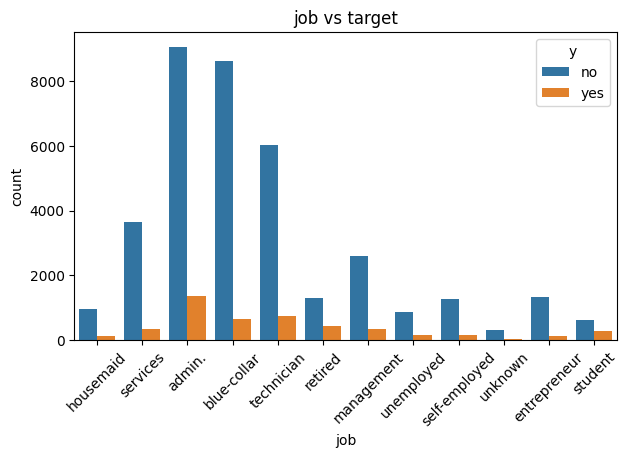

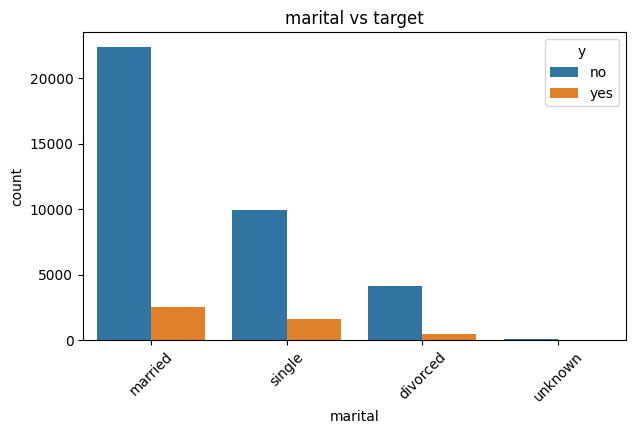

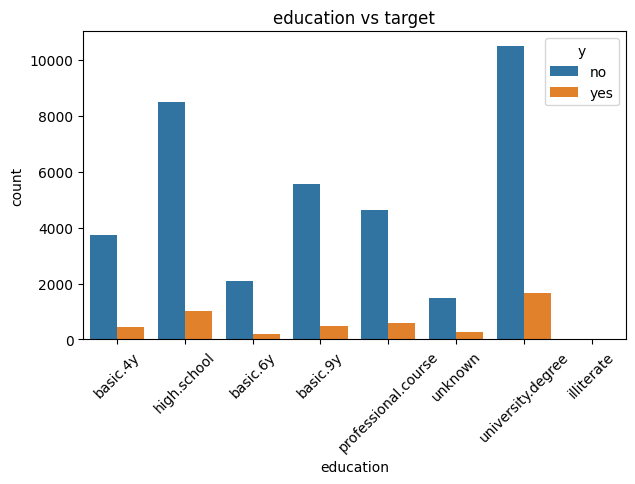

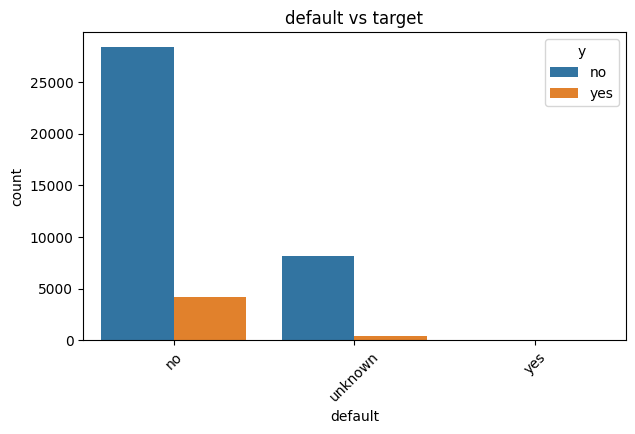

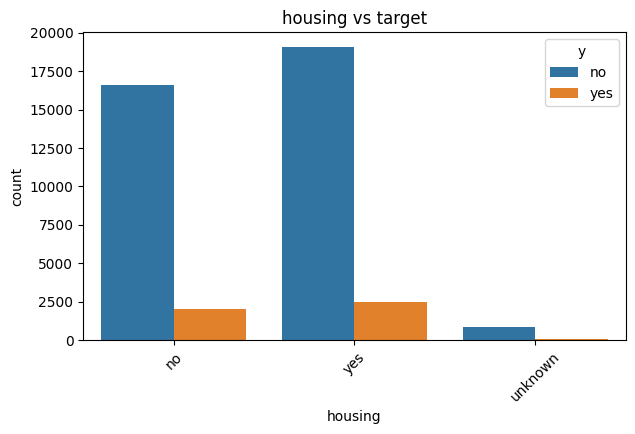

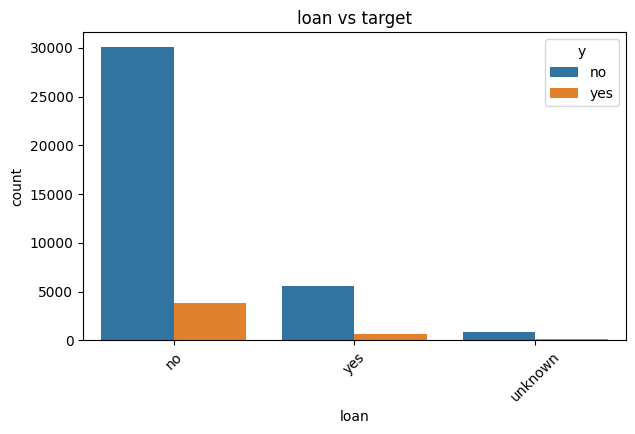

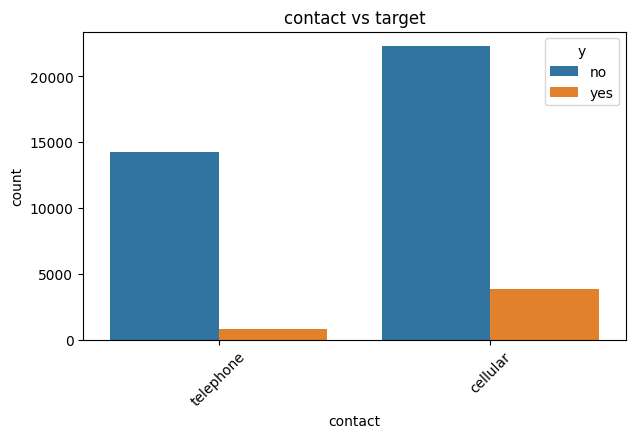

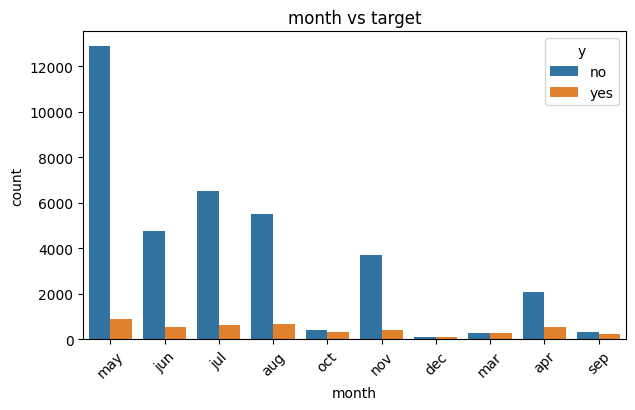

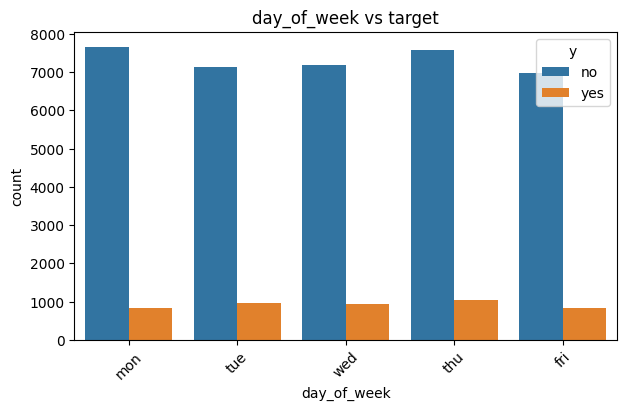

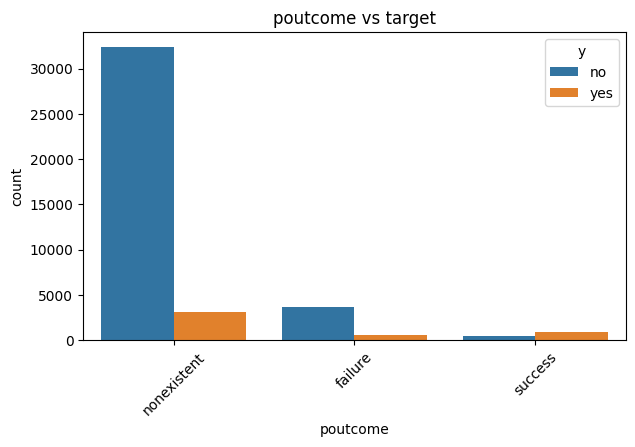

In [15]:
for col in categorical:
    if col != 'y':
        plt.figure(figsize=(7,4))
        sns.countplot(data=df, x=col, hue='y')
        plt.title(f'{col} vs target')
        plt.xticks(rotation=45)
        plt.show()

Аналіз bar-plotів показує, що кількість клієнтів, які не погодилися оформити депозит (no), значно перевищує кількість тих, хто погодився (yes). Це свідчить про суттєвий дисбаланс класів у цільовій змінній, що потрібно враховувати при побудові моделей машинного навчання.


###Професія (job)
Найбільшу частку клієнтів становлять категорії admin, technician та blue-collar.
Водночас відносно вища частка позитивних відповідей (yes) спостерігається серед пенсіонерів (retired) та студентів (student), що може свідчити про їхню більшу зацікавленість у накопиченні коштів.

###Сімейний стан (marital)
Найбільша кількість клієнтів належить до категорії married, що є очікуваним для дорослого населення. Проте суттєвих відмінностей у співвідношенні yes і no між категоріями marital не спостерігається, тому сімейний стан не виглядає сильним фактором, який впливає на рішення про відкриття депозиту.

###Освіта (education)
Найбільше клієнтів мають освіту high school та university degree. У всіх категоріях освіти домінує відповідь no, але клієнти з вищою освітою (university degree) демонструють дещо більшу кількість позитивних відповідей, що може бути пов’язано з вищим рівнем доходу або фінансової грамотності.

###Прострочений кредит (default)
Більшість клієнтів не мають прострочених кредитів (no), а категорія yes практично відсутня. Через малу кількість таких випадків складно робити значущі висновки щодо впливу цієї змінної на рішення про відкриття депозиту.

###Іпотечний кредит (housing)
Розподіл між категоріями yes та no є відносно рівномірним, і чіткої різниці у частці клієнтів, які погоджуються на депозит, не спостерігається. Це може свідчити про те, що наявність іпотечного кредиту не є сильним фактором для прийняття рішення.

###Споживчий кредит (loan)
Більшість клієнтів не мають споживчого кредиту, і серед них також спостерігається більше випадків відкриття депозиту. Однак загальний патерн знову ж таки відповідає загальному дисбалансу таргетної змінної.
Тип контакту (contact)
Клієнти, з якими банк зв’язувався через мобільний зв’язок (cellular), значно частіше погоджувалися на депозит порівняно з клієнтами, яких контактували через стаціонарний телефон (telephone). Це може свідчити про вищу ефективність мобільного каналу комунікації.

###Місяць контакту (month)
Кількість контактів суттєво відрізняється між місяцями. Найбільше контактів було здійснено у травні, проте частка позитивних відповідей відносно невелика. Деякі інші місяці демонструють відносно більшу частку yes, що може свідчити про сезонність у результатах маркетингових кампаній.

###День тижня (day_of_week)
Розподіл контактів за днями тижня є досить рівномірним, і суттєвих відмінностей у частці клієнтів, які погодилися на депозит, між днями тижня не спостерігається.

###Результат попередньої кампанії (poutcome)
Ця змінна демонструє найбільш помітний зв’язок із цільовою змінною. Клієнти, які мали успішний результат у попередній маркетинговій кампанії (success), значно частіше погоджуються на відкриття депозиту. Це свідчить про те, що історія попередніх контактів є важливим фактором для прогнозування поведінки клієнтів.

##Гіпотези

###Гіпотеза 1:
Клієнти з професією retired або student мають вищу ймовірність оформлення депозиту, ніж інші професійні групи.
Обґрунтування:
З графіків видно, що у цих категоріях відносна частка відповідей yes вища. Це може бути пов’язано з тим, що пенсіонери мають накопичення, а студенти можуть використовувати депозит як спосіб заощадження коштів.

###Гіпотеза 2:
Клієнти з вищою освітою (university degree) частіше погоджуються на відкриття депозиту.
Обґрунтування:
Особи з вищою освітою можуть мати: вищий дохід, кращу фінансову грамотність, більшу схильність до інвестицій і заощаджень.

###Гіпотеза 3:
Контакт через мобільний телефон (cellular) є ефективнішим для підписання депозиту, ніж контакт через стаціонарний телефон (telephone).
Обґрунтування:
З bar-plot видно, що частка позитивних відповідей значно більша серед клієнтів, з якими зв’язувалися через мобільний телефон.

###Гіпотеза 4:
Клієнти, які мали успішний результат у попередній маркетинговій кампанії (success), мають значно вищу ймовірність погодитися на депозит.
Обґрунтування:
Попередній позитивний досвід взаємодії з банком може підвищувати довіру клієнта до фінансових продуктів.

###Гіпотеза 5:
Клієнти, з якими банк вже контактував у попередніх кампаніях, мають більшу ймовірність погодитися на депозит.
Обґрунтування:
Спостерігається позитивна кореляція між previous і цільовою змінною (≈ 0.23), що може свідчити про підвищений рівень довіри клієнтів, які вже взаємодіяли з банком.

###Гіпотеза 6:
Чим менше часу минуло з моменту попереднього контакту з клієнтом, тим більша ймовірність успішного підписання депозиту.
Обґрунтування:
Спостерігається негативна кореляція (≈ -0.32), що може означати, що клієнти, з якими недавно контактували, більш схильні погодитися на депозит.

###Гіпотеза 7:
Погіршення економічної ситуації може збільшувати ймовірність відкриття депозиту.
Обґрунтування:
Спостерігається негативна кореляція між цільовою змінною та макроекономічними показниками: euribor3m, emp.var.rate, nr.employed
Це може свідчити про те, що у періоди економічної нестабільності клієнти частіше обирають заощадження як більш безпечну фінансову стратегію.

###Гіпотеза 8:
Ймовірність підписання депозиту залежить від місяця контакту, що може свідчити про сезонність маркетингової кампанії.
Обґрунтування:
На графіку видно, що кількість позитивних відповідей змінюється залежно від місяця.

##Метод оцінки моделі -- F1-Score

Оскільки цільова змінна має суттєвий дисбаланс між класами (yes значно менше ніж no), використання лише accuracy може давати оманливі результати. Тому для оцінки моделей доцільно використовувати метрики, що враховують баланс між помилками класифікації, такі як precision(серед усіх прогнозів yes, скільки були правильні), recall(скільки реальних yes модель змогла знайти) та F1-score(баланс між precision і recall). Крім того, для порівняння моделей можна використовувати ROC-AUC, який оцінює здатність моделі відрізняти позитивний і негативний класи.

###Логістична регресія (Baseline)

Як працює?



*   Спочатку модель рахує лінійну комбінацію ознак
*   Потім пропускає це через sigmoid-функцію
*   В результаті отримуємо число від 0 до 1
*   Потім модельприймає рішення по кожному значені в тестовій вибірці, тобто вчиться.

В данному випадку маємо стандартний threshold = 0.5
якщо ≥ 0.5 → клас 1 (yes)
якщо < 0.5 → клас 0 (no)     



In [16]:
df_model = df.drop(columns=["duration"]).copy()

X = df_model.drop(columns=["y"])
y = df_model["y"].map({"no": 0, "yes": 1})


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [17]:
def feature_engineering(X):
    X = X.copy()


    cat_cols = X.select_dtypes(include="object").columns
    for col in cat_cols:
        X[col] = X[col].replace("unknown", np.nan)

    if "previous" in X.columns:
        X["was_contacted_before"] = (X["previous"] > 0).astype(int)

    if "pdays" in X.columns:
        X["previous_campaign_contact"] = (X["pdays"] != 999).astype(int)
        X["pdays_clean"] = X["pdays"].replace(999, np.nan)
        X = X.drop(columns=["pdays"])

    if {"housing", "loan"}.issubset(X.columns):
        X["has_any_loan"] = (
            ((X["housing"] == "yes") | (X["loan"] == "yes")).astype(int)
        )

    if "campaign" in X.columns:
        X["campaign_group"] = pd.cut(
            X["campaign"],
            bins=[-np.inf, 1, 3, 6, np.inf],
            labels=["1", "2-3", "4-6", "7+"]
        )

    if "age" in X.columns:
        X["age_group"] = pd.cut(
            X["age"],
            bins=[0, 25, 40, 60, 100],
            labels=["18-25", "26-40", "41-60", "60+"]
        )

    return X


feature_transformer = FunctionTransformer(feature_engineering)

In [18]:
X_train_fe = feature_engineering(X_train)

cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

pipeline = ImbPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineering)),
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function feature_engineering at 0x7edd7bf52de0>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'campaign',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.e...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome', 'campaign_group',
                                                   'age_group'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [19]:
y_pred_train = pipeline.predict(X_train)
y_proba_train = pipeline.predict_proba(X_train)[:,1]
y_pred_val = pipeline.predict(X_val)
y_proba_val = pipeline.predict_proba(X_val)[:, 1]
y_pred_test = pipeline.predict(X_test)
y_proba_test = pipeline.predict_proba(X_test)[:, 1]

In [20]:
print(f"Train LogisticRegression")
print(classification_report(y_train, y_pred_train))
print("Val LogisticRegression")
print(classification_report(y_val, y_pred_val))
print("Test LogisticRegression")
print(classification_report(y_test, y_pred_test))
print("Train ROC-AUC LogisticRegression:", roc_auc_score(y_train, y_proba_train))
print("Val ROC-AUC LogisticRegression:", roc_auc_score(y_val, y_proba_val))
print("Test ROC-AUC LogisticRegression:", roc_auc_score(y_test, y_proba_test))

Train LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.84      0.89     21928
           1       0.34      0.63      0.44      2784

    accuracy                           0.82     24712
   macro avg       0.64      0.74      0.67     24712
weighted avg       0.88      0.82      0.84     24712

Val LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

Test LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      7310
           1       0.35      0.65      0.45       928

    accuracy                           0.82      8238
   macro avg       0.65      0.75      0.67      8238
we

In [21]:
pipeline.named_steps["model"].get_params()

{'C': 1.0,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 2000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

Модель логістичної регресії показує стабільні результати на train, validation та test наборах, що свідчить про відсутність переобучення та коректну побудову пайплайну.
Основною проблемою є низька якість прогнозування для позитивного класу (клієнти, що погоджуються на депозит): при recall 0.65 модель має низький precision (0.35), що призводить до великої кількості хибнопозитивних прогнозів.
Це означає, що модель схильна переоцінювати ймовірність згоди клієнта, що може бути неефективним з точки зору бізнес-витрат.
Таким чином, подальше покращення моделі має бути спрямоване на оптимізацію F1-score для класу "yes" та баланс між precision і recall.

###Логістична регресія зі зміненим  threshold-ем

In [22]:
thresholds = np.arange(0.1, 0.9, 0.01)
scores = []

for t in thresholds:
    y_pred_temp = (y_proba_val >= t).astype(int)
    scores.append(f1_score(y_val, y_pred_temp))

best_t = thresholds[np.argmax(scores)]

print("Best threshold:", best_t)

Best threshold: 0.6599999999999997


In [23]:
y_proba_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_t).astype(int)

print(f"Train LogisticRegression")
print(classification_report(y_train, y_pred_train))
print("Test LogisticRegression")
print(classification_report(y_val, y_pred_val))
print("Test LogisticRegression")
print(classification_report(y_test, y_pred_test))
print("Train ROC-AUC LogisticRegression:", roc_auc_score(y_train, y_proba_train))
print("Val ROC-AUC LogisticRegression:", roc_auc_score(y_val, y_proba_val))
print("Test ROC-AUC LogisticRegression:", roc_auc_score(y_test, y_proba_test))

Train LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.84      0.89     21928
           1       0.34      0.63      0.44      2784

    accuracy                           0.82     24712
   macro avg       0.64      0.74      0.67     24712
weighted avg       0.88      0.82      0.84     24712

Test LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

Test LogisticRegression
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      7310
           1       0.44      0.56      0.49       928

    accuracy                           0.87      8238
   macro avg       0.69      0.74      0.71      8238
w

In [24]:
pipeline.named_steps["model"].get_params()

{'C': 1.0,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 2000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

Модель логістичної регресії демонструє стабільні результати на всіх вибірках без ознак переобучення. Після оптимізації порогу класифікації вдалося покращити якість прогнозування для позитивного класу: precision зріс з ~0.35 до ~0.44, а F1-score — з ~0.45 до ~0.49.
Це свідчить про зменшення кількості хибнопозитивних прогнозів і підвищення надійності моделі з точки зору бізнесу. Водночас відбулося незначне зниження recall, що є очікуваним компромісом.
Таким чином, threshold tuning дозволив досягти кращого балансу між precision та recall і підвищити практичну цінність моделі.

###Модель RandomForestClassifier

Як працює?

*   Створюється багато випадкових підвибірок з тренувальних даних (bootstrap)
*   Для кожної підвибірки будується окреме дерево рішень
*   Кожне дерево навчається незалежно та використовує випадкову частину ознак
*   Для кожного об’єкта в тестовій вибірці кожне дерево робить прогноз(дивиться на клієнта і каже: yes або no. Фінальний результат визначається більшістю голосів або як частка голосів за позитивний клас)

In [25]:
pipeline_Random_forest = ImbPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineering)),
    ("preprocessor", preprocessor), # Add this step to handle NaN values and encode categorical features
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(class_weight="balanced"))
])

In [26]:
pipeline_Random_forest.fit(X_train, y_train)

y_pred_forest_train = pipeline_Random_forest.predict(X_train)
y_proba_forest_train = pipeline_Random_forest.predict_proba(X_train)[:, 1]
y_pred_forest_val = pipeline_Random_forest.predict(X_val)
y_proba_forest_val = pipeline_Random_forest.predict_proba(X_val)[:, 1]
y_pred_forest_test = pipeline_Random_forest.predict(X_test)
y_proba_forest_test = pipeline_Random_forest.predict_proba(X_test)[:, 1]

print("Train RandomForestClassifier", classification_report(y_train, y_pred_forest_train))
print("Val RandomForestClassifier", classification_report(y_val, y_pred_forest_val))
print("Test RandomForestClassifier", classification_report(y_test, y_pred_forest_test))
print("Train ROC-AUC RandomForestClassifier", roc_auc_score(y_train, y_proba_forest_train))
print("Val ROC-AUC RandomForestClassifier", roc_auc_score(y_val, y_proba_forest_val))
print("Test ROC-AUC RandomForestClassifier", roc_auc_score(y_test, y_proba_forest_test))

Train RandomForestClassifier               precision    recall  f1-score   support

           0       1.00      1.00      1.00     21928
           1       0.99      0.98      0.98      2784

    accuracy                           1.00     24712
   macro avg       0.99      0.99      0.99     24712
weighted avg       1.00      1.00      1.00     24712

Val RandomForestClassifier               precision    recall  f1-score   support

           0       0.92      0.96      0.94      7310
           1       0.52      0.35      0.42       928

    accuracy                           0.89      8238
   macro avg       0.72      0.66      0.68      8238
weighted avg       0.88      0.89      0.88      8238

Test RandomForestClassifier               precision    recall  f1-score   support

           0       0.92      0.96      0.94      7310
           1       0.50      0.34      0.40       928

    accuracy                           0.89      8238
   macro avg       0.71      0.65      0.67 

In [27]:
pipeline_Random_forest.named_steps["model"].get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

Модель Random Forest демонструє значне переобучення: майже ідеальні результати на тренувальній вибірці не підтверджуються на валідаційній та тестовій. Незважаючи на прийнятний рівень accuracy (0.89), модель має низький recall для позитивного класу (0.35), що означає втрату значної кількості потенційних клієнтів.
У порівнянні з Logistic Regression, Random Forest показує гірший баланс між precision та recall і нижчий F1-score для класу "yes". Таким чином, у поточному вигляді модель є менш ефективною для даної задачі.

###Метод найближчих сусідів або “Скажи мені, хто твої сусіди — і я скажу, хто ти”

Як працює?

*  Для кожного об’єкта в тестовій вибірці модель знаходить k найближчих сусідів у тренувальних даних
*  Близькість визначається за метрикою відстані (наприклад, Euclidean distance)
*  Серед знайдених сусідів модель дивиться, до якого класу вони належать
*  Фінальний результат для обʼєкта зазначається клас, який зустрічається найчастіше серед k сусідів.

In [28]:
pipeline_knn = ImbPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineering)),
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", KNeighborsClassifier())
])

pipeline_knn.fit(X_train, y_train)
y_pred_knn_train = pipeline_knn.predict(X_train)
y_proba_knn_train = pipeline_knn.predict_proba(X_train)[:, 1]
y_pred_knn_val = pipeline_knn.predict(X_val)
y_proba_knn_val = pipeline_knn.predict_proba(X_val)[:, 1]
y_pred_knn_test = pipeline_knn.predict(X_test)
y_proba_knn_test = pipeline_knn.predict_proba(X_test)[:, 1]

print("Train KNN", classification_report(y_train, y_pred_knn_train))
print("Val KNN", classification_report(y_val, y_pred_knn_val))
print("Test KNN", classification_report(y_test, y_pred_knn_test))
print("Train ROC-AUC KNN:", roc_auc_score(y_train, y_proba_knn_train))
print("Val ROC-AUC KNN:", roc_auc_score(y_val, y_proba_knn_val))
print("Test ROC-AUC KNN:", roc_auc_score(y_test, y_proba_knn_test))

Train KNN               precision    recall  f1-score   support

           0       1.00      0.79      0.88     21928
           1       0.37      0.98      0.54      2784

    accuracy                           0.81     24712
   macro avg       0.69      0.89      0.71     24712
weighted avg       0.93      0.81      0.84     24712

Val KNN               precision    recall  f1-score   support

           0       0.94      0.72      0.82      7310
           1       0.23      0.66      0.34       928

    accuracy                           0.71      8238
   macro avg       0.59      0.69      0.58      8238
weighted avg       0.86      0.71      0.76      8238

Test KNN               precision    recall  f1-score   support

           0       0.94      0.73      0.82      7310
           1       0.23      0.64      0.34       928

    accuracy                           0.72      8238
   macro avg       0.58      0.68      0.58      8238
weighted avg       0.86      0.72      0.77    

In [29]:
pipeline_knn.named_steps["model"].get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

Модель KNN демонструє ознаки переобучення: якість на тренувальній вибірці значно вища, ніж на валідаційній та тестовій. Зокрема, ROC-AUC знижується з ~0.98 на train до ~0.72 на val/test, що свідчить про обмежену здатність моделі до узагальнення.

### KNN без генерування штучних данних

In [30]:
pipeline_knn = ImbPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineering)),
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

pipeline_knn.fit(X_train, y_train)
y_pred_knn_train = pipeline_knn.predict(X_train)
y_proba_knn_train = pipeline_knn.predict_proba(X_train)[:, 1]
y_pred_knn_val = pipeline_knn.predict(X_val)
y_proba_knn_val = pipeline_knn.predict_proba(X_val)[:, 1]
y_pred_knn_test = pipeline_knn.predict(X_test)
y_proba_knn_test = pipeline_knn.predict_proba(X_test)[:, 1]

print("Train KNN", classification_report(y_train, y_pred_knn_train))
print("Val KNN", classification_report(y_val, y_pred_knn_val))
print("Test KNN", classification_report(y_test, y_pred_knn_test))
print("Train ROC-AUC KNN:", roc_auc_score(y_train, y_proba_knn_train))
print("Val ROC-AUC KNN:", roc_auc_score(y_val, y_proba_knn_val))
print("Test ROC-AUC KNN:", roc_auc_score(y_test, y_proba_knn_test))

Train KNN               precision    recall  f1-score   support

           0       0.92      0.98      0.95     21928
           1       0.73      0.35      0.47      2784

    accuracy                           0.91     24712
   macro avg       0.83      0.67      0.71     24712
weighted avg       0.90      0.91      0.90     24712

Val KNN               precision    recall  f1-score   support

           0       0.91      0.98      0.94      7310
           1       0.57      0.26      0.36       928

    accuracy                           0.89      8238
   macro avg       0.74      0.62      0.65      8238
weighted avg       0.87      0.89      0.88      8238

Test KNN               precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.56      0.26      0.36       928

    accuracy                           0.89      8238
   macro avg       0.73      0.62      0.65      8238
weighted avg       0.87      0.89      0.88    

In [31]:
pipeline_knn.named_steps["model"].get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

Після відмови від використання SMOTE модель KNN демонструє зміну балансу між precision та recall. Зокрема, precision для класу "yes" суттєво зріс (з ~0.23 до ~0.56), що свідчить про зменшення кількості хибнопозитивних прогнозів. Водночас recall значно знизився (до ~0.26), тобто модель почала пропускати більшість позитивних випадків.
Таким чином, SMOTE не погіршував модель, а змінював її поведінку: з його використанням модель краще знаходила позитивний клас, але з більшою кількістю помилок, тоді як без SMOTE вона стала більш точною, але менш чутливою до позитивних прикладів.

## Boosting

### XGBoost


Як працює?

XGBoost базується на деревах рішень, але використовує підхід градієнтного бустингу, де кожне дерево навчається на помилках попередніх, використовуючи градієнти функції втрат.

XGBoost = дерева рішень + градієнтна оптимізація + регуляризація

In [32]:
num_cols_xgb = X_train_fe.select_dtypes(include=np.number).columns.tolist()
cat_cols_xgb = X_train_fe.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_pipeline_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor_xgb = ColumnTransformer([
    ("num", numeric_pipeline_xgb, num_cols_xgb),
    ("cat", categorical_pipeline_xgb, cat_cols_xgb)
])

pipeline_xgb = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor_xgb),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb_train = pipeline_xgb.predict(X_train)
y_proba_xgb_train = pipeline_xgb.predict_proba(X_train)[:, 1]
y_pred_xgb_val = pipeline_xgb.predict(X_val)
y_proba_xgb_val = pipeline_xgb.predict_proba(X_val)[:, 1]
y_pred_xgb_test = pipeline_xgb.predict(X_test)
y_proba_xgb_test = pipeline_xgb.predict_proba(X_test)[:, 1]

print("Train XGB", classification_report(y_train, y_pred_xgb_train))
print("Val XGB", classification_report(y_val, y_pred_xgb_val))
print("Test XGB", classification_report(y_test, y_pred_xgb_test))
print("Train ROC-AUC XGB:", roc_auc_score(y_train, y_proba_xgb_train))
print("Val ROC-AUC:", roc_auc_score(y_val, y_proba_xgb_val))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_test))

Train XGB               precision    recall  f1-score   support

           0       0.93      0.98      0.95     21928
           1       0.69      0.38      0.49      2784

    accuracy                           0.91     24712
   macro avg       0.81      0.68      0.72     24712
weighted avg       0.90      0.91      0.90     24712

Val XGB               precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.58      0.33      0.42       928

    accuracy                           0.90      8238
   macro avg       0.75      0.65      0.68      8238
weighted avg       0.88      0.90      0.88      8238

Test XGB               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7310
           1       0.61      0.31      0.41       928

    accuracy                           0.90      8238
   macro avg       0.76      0.64      0.68      8238
weighted avg       0.88      0.90      0.89    

In [33]:
pipeline_xgb.named_steps["model"].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 300,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Модель XGBoost демонструє стабільні результати на тренувальній, валідаційній та тестовій вибірках (ROC-AUC 0.80), що свідчить про відсутність значного переобучення.
У порівнянні з попередніми моделями, XGBoost покращує precision для позитивного класу (0.61), що означає зменшення кількості хибнопозитивних прогнозів. Хоча все ще спостерігається низький recall (0.31), тобто модель пропускає значну частину клієнтів, які погоджуються на депозит.
Таким чином, бустинг дозволив отримати більш точні, але більш консервативні прогнози. Модель робить менше помилок, але знаходить менше позитивних випадків.

In [34]:
pipeline_xgb_main = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor_xgb),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    ))
])

pipeline_xgb_main.fit(X_train, y_train)
y_pred_xgb_train_main = pipeline_xgb_main.predict(X_train)
y_proba_xgb_train_main = pipeline_xgb_main.predict_proba(X_train)[:, 1]
y_pred_xgb_val_main = pipeline_xgb_main.predict(X_val)
y_proba_xgb_val_main = pipeline_xgb_main.predict_proba(X_val)[:, 1]
y_pred_xgb_test_main = pipeline_xgb_main.predict(X_test)
y_proba_xgb_test_main = pipeline_xgb_main.predict_proba(X_test)[:, 1]

print("Train XGB with scale_pos_weight and without SMOTE", classification_report(y_train, y_pred_xgb_train_main))
print("Val XGB with scale_pos_weight and without SMOTE", classification_report(y_val, y_pred_xgb_val_main))
print("Test XGB with scale_pos_weight and without SMOTE",classification_report(y_test, y_pred_xgb_test_main))
print("Train ROC-AUC XGB with scale_pos_weight and without SMOTE:", roc_auc_score(y_train, y_proba_xgb_train_main))
print("Val ROC-AUC:", roc_auc_score(y_val, y_proba_xgb_val_main))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_test_main))

Train XGB with scale_pos_weight and without SMOTE               precision    recall  f1-score   support

           0       0.96      0.88      0.92     21928
           1       0.42      0.70      0.53      2784

    accuracy                           0.86     24712
   macro avg       0.69      0.79      0.72     24712
weighted avg       0.90      0.86      0.87     24712

Val XGB with scale_pos_weight and without SMOTE               precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.40      0.64      0.49       928

    accuracy                           0.85      8238
   macro avg       0.68      0.76      0.70      8238
weighted avg       0.89      0.85      0.87      8238

Test XGB with scale_pos_weight and without SMOTE               precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.62      0.48       928

    accuracy                       

In [35]:
pipeline_xgb_main.named_steps["model"].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 300,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': np.float64(7.876436781609195),
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Після відмови від SMOTE та використання scale_pos_weight вдалося досягти кращого балансу між precision та recall. Модель демонструє вищу точність прогнозів у порівнянні з варіантом із SMOTE, зберігаючи при цьому достатньо високий рівень recall.

###LGBOOST + Hyperopt

Як працює?

*  Модель будує дерева рішень послідовно (boosting)
*  Перше дерево робить базовий прогноз
*  Кожне наступне дерево навчається на помилках попередніх
*  Кожне нове дерево покращує попередній результат

####При цьому модель приділяє більше уваги тим об’єктам, на яких попередні моделі помилилися, і намагається зменшити ці помилки на наступних кроках.

In [36]:
X_val_lgb = feature_engineering(X_val)
X_test_lgb = feature_engineering(X_test)
X_train_lgb = feature_engineering(X_train)

In [37]:
cat_cols = X_train_fe.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    X_val_lgb[col] = X_val_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")
    X_train_lgb[col] = X_train_lgb[col].astype("category")

In [38]:
def objective(params):
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"] = int(params["max_depth"])
    params["num_leaves"] = int(params["num_leaves"])
    params["min_child_samples"] = int(params["min_child_samples"])

    clf = lgb.LGBMClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        num_leaves=params["num_leaves"],
        min_child_samples=params["min_child_samples"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        reg_alpha=params["reg_alpha"],
        reg_lambda=params["reg_lambda"],
        min_split_gain=params["min_split_gain"],
        objective="binary",
        random_state=42,
        class_weight="balanced",
        verbose=-1
    )

    clf.fit(
        X_train_lgb,
        y_train,
        eval_set=[(X_val_lgb, y_val)],
        eval_metric="auc",
        categorical_feature=cat_cols
    )

    val_proba = clf.predict_proba(X_val_lgb)[:, 1]
    auc = roc_auc_score(y_val, val_proba)

    return {"loss": -auc, "status": STATUS_OK}

In [39]:
space = {
    "n_estimators": hp.quniform("n_estimators", 100, 500, 25),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.15),
    "max_depth": hp.quniform("max_depth", 3, 10, 1),
    "num_leaves": hp.quniform("num_leaves", 20, 120, 1),
    "min_child_samples": hp.quniform("min_child_samples", 10, 50, 1),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
    "reg_alpha": hp.uniform("reg_alpha", 0.0, 2.0),
    "reg_lambda": hp.uniform("reg_lambda", 0.0, 2.0),
    "min_split_gain": hp.uniform("min_split_gain", 0.0, 0.2)
}

In [40]:
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=25,
    trials=trials,
    rstate=np.random.default_rng(42)
)

best["n_estimators"] = int(best["n_estimators"])
best["max_depth"] = int(best["max_depth"])
best["num_leaves"] = int(best["num_leaves"])
best["min_child_samples"] = int(best["min_child_samples"])

print("Найкращі гіперпараметри:", best)

100%|██████████| 25/25 [00:40<00:00,  1.61s/trial, best loss: -0.812725467592811]
Найкращі гіперпараметри: {'colsample_bytree': np.float64(0.7208716005397193), 'learning_rate': np.float64(0.013197997857263208), 'max_depth': 6, 'min_child_samples': 15, 'min_split_gain': np.float64(0.00019066638592776797), 'n_estimators': 275, 'num_leaves': 30, 'reg_alpha': np.float64(1.4528944916324902), 'reg_lambda': np.float64(0.6859642198840514), 'subsample': np.float64(0.8432450507622776)}


In [41]:
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best["n_estimators"],
    learning_rate=best["learning_rate"],
    max_depth=best["max_depth"],
    num_leaves=best["num_leaves"],
    min_child_samples=best["min_child_samples"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample_bytree"],
    reg_alpha=best["reg_alpha"],
    reg_lambda=best["reg_lambda"],
    min_split_gain=best["min_split_gain"],
    objective="binary",
    random_state=42,
    class_weight="balanced",
    verbose=-1
)

final_lgb_clf.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_val_lgb, y_val)],
    eval_metric="auc",
    categorical_feature=cat_cols
)

train_pred_lgb = final_lgb_clf.predict(X_train_lgb)
train_proba_lgb = final_lgb_clf.predict_proba(X_train_lgb)[:, 1]
val_pred_lgb = final_lgb_clf.predict(X_val_lgb)
val_proba_lgb = final_lgb_clf.predict_proba(X_val_lgb)[:, 1]
test_pred_lgb = final_lgb_clf.predict(X_test_lgb)
test_proba_lgb = final_lgb_clf.predict_proba(X_test_lgb)[:, 1]

train_auc = roc_auc_score(y_train, train_proba_lgb)
val_auc = roc_auc_score(y_val, val_proba_lgb)
tpe_test_auc = roc_auc_score(y_test, test_proba_lgb)

print("Traine Lgb with HP", classification_report(y_train, train_pred_lgb))
print("Val Lgb with HP", classification_report(y_val, val_pred_lgb))
print("Test Lgb with HP", classification_report(y_test, test_pred_lgb))
print(f"Train AUROC with HP: {train_auc:.4f}")
print(f"Validation AUROC with HP: {val_auc:.4f}")
print(f"Test AUROC with HP: {tpe_test_auc:.4f}")

Traine Lgb with HP               precision    recall  f1-score   support

           0       0.95      0.88      0.91     21928
           1       0.40      0.64      0.49      2784

    accuracy                           0.85     24712
   macro avg       0.67      0.76      0.70     24712
weighted avg       0.89      0.85      0.86     24712

Val Lgb with HP               precision    recall  f1-score   support

           0       0.95      0.88      0.92      7310
           1       0.42      0.66      0.51       928

    accuracy                           0.86      8238
   macro avg       0.68      0.77      0.71      8238
weighted avg       0.89      0.86      0.87      8238

Test Lgb with HP               precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.40      0.64      0.50       928

    accuracy                           0.85      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.8

In [42]:
print(final_lgb_clf)

LGBMClassifier(class_weight='balanced',
               colsample_bytree=np.float64(0.7208716005397193),
               learning_rate=np.float64(0.013197997857263208), max_depth=6,
               min_child_samples=15,
               min_split_gain=np.float64(0.00019066638592776797),
               n_estimators=275, num_leaves=30, objective='binary',
               random_state=42, reg_alpha=np.float64(1.4528944916324902),
               reg_lambda=np.float64(0.6859642198840514),
               subsample=np.float64(0.8432450507622776), verbose=-1)


Модель LightGBM з підібраними гіперпараметрами демонструє стабільні результати на тренувальній, валідаційній та тестовій вибірках (AUROC 0.81–0.83), що свідчить про відсутність переобучення та хорошу узагальнюючу здатність.
Для позитивного класу модель досягла збалансованого співвідношення precision (0.40) та recall (0.64), що забезпечує найкращий F1-score (0.50) серед усіх розглянутих моделей.
Таким чином, LightGBM є найбільш ефективною моделлю для даної задачі, оскільки забезпечує оптимальний баланс між точністю прогнозів і здатністю виявляти клієнтів, які погоджуються на депозит.

###LGBOOST + RandomizedSearchCV
метод для пошуку оптимальних гіперпараметрів моделі

In [43]:
param_dist = {
    "num_leaves": [20, 25, 30, 35, 40],
    "learning_rate": [0.005, 0.01, 0.013, 0.02],
    "max_depth": [4, 5, 6, 7, 8],
    "min_child_samples": [10, 15, 20, 25],
    "n_estimators": [200, 250, 275, 300, 350],
    "subsample": [0.75, 0.8, 0.84, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.72, 0.8],
    "reg_alpha": [0.5, 1.0, 1.45, 2.0],
    "reg_lambda": [0.3, 0.5, 0.68, 1.0],
    "min_split_gain": [0.0, 0.0001, 0.001]
}

In [44]:
search = RandomizedSearchCV(estimator=final_lgb_clf, param_distributions=param_dist, n_iter=10, cv=5, scoring='f1', random_state=42, verbose=1, n_jobs=-1)

In [45]:
search.fit(X_train_lgb, y_train, categorical_feature=cat_cols)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(class_weight='balanced',
                                            colsample_bytree=np.float64(0.7208716005397193),
                                            learning_rate=np.float64(0.013197997857263208),
                                            max_depth=6, min_child_samples=15,
                                            min_split_gain=np.float64(0.00019066638592776797),
                                            n_estimators=275, num_leaves=30,
                                            objective='binary', random_state=42,
                                            reg_alpha=np.float64(1.4528944916...
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.72,
                                                             0.8],
                                        'learning_rate': [0.005, 0.01, 0.013,
                                                          0.02],
                                        'max_depth': [4, 5, 6, 7, 8],
                                        'min_child_samples': [10, 15, 20, 25],
                                        'min_split_gain': [0.0, 0.0001, 0.001],
                                        'n_estimators': [200, 250, 275, 300,
                                                         350],
                                        'num_leaves': [20, 25, 30, 35, 40],
                                        'reg_alpha': [0.5, 1.0, 1.45, 2.0],
                                        'reg_lambda': [0.3, 0.5, 0.68, 1.0],
                                        'subsample': [0.75, 0.8, 0.84, 0.9]},
                   random_state=42, scoring='f1', verbose=1)

In [46]:
best_model = search.best_estimator_

print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)

Best params: {'subsample': 0.84, 'reg_lambda': 0.68, 'reg_alpha': 1.45, 'num_leaves': 40, 'n_estimators': 350, 'min_split_gain': 0.001, 'min_child_samples': 15, 'max_depth': 7, 'learning_rate': 0.013, 'colsample_bytree': 0.6}
Best CV F1: 0.4744126248081134


In [47]:
y_perd_search_train = best_model.predict(X_train_lgb)
y_proba_search_train = best_model.predict_proba(X_train_lgb)[:, 1]
y_pred_search_val = best_model.predict(X_val_lgb)
y_proba_search_val = best_model.predict_proba(X_val_lgb)[:, 1]
y_pred_search_test = best_model.predict(X_test_lgb)
y_proba_search_test = best_model.predict_proba(X_test_lgb)[:, 1]

print("Train search", classification_report(y_train, y_perd_search_train))
print("Val search", classification_report(y_val, y_pred_search_val))
print("Test search", classification_report(y_test, y_pred_search_test))

print("Train ROC-AUC:", roc_auc_score(y_train, y_proba_search_train))
print("Val ROC-AUC:", roc_auc_score(y_val, y_proba_search_val))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_search_test))

Train search               precision    recall  f1-score   support

           0       0.95      0.88      0.91     21928
           1       0.41      0.65      0.50      2784

    accuracy                           0.85     24712
   macro avg       0.68      0.77      0.71     24712
weighted avg       0.89      0.85      0.87     24712

Val search               precision    recall  f1-score   support

           0       0.95      0.89      0.92      7310
           1       0.42      0.66      0.51       928

    accuracy                           0.86      8238
   macro avg       0.69      0.77      0.72      8238
weighted avg       0.89      0.86      0.87      8238

Test search               precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.40      0.64      0.50       928

    accuracy                           0.85      8238
   macro avg       0.68      0.76      0.70      8238
weighted avg       0.89      0.85     

Було проведено підбір гіперпараметрів за допомогою різних методів, зокрема RandomizedSearchCV та іншого підходу оптимізації. Отримані результати виявилися практично однаковими за всіма основними метриками (F1-score, ROC-AUC), що свідчить про досягнення оптимального рівня якості моделі.
Найкращою моделлю є LightGBM з Search, оскільки вона демонструє найвищий F1-score на тестовій вибірці (0.50) та забезпечує оптимальний баланс між precision (0.40) і recall (0.64). Модель не має ознак переобучення (однакові метрики на train і test), що свідчить про хорошу узагальнюючу здатність. У порівнянні з іншими моделями, LightGBM дозволяє ефективно виявляти клієнтів, які погоджуються на депозит, при помірній кількості хибнопозитивних прогнозів, що робить її найбільш придатною для бізнес-застосування.

###Аналіз важливості ознак в моделі

In [48]:
booster = best_model.booster_
importance_gain = booster.feature_importance(importance_type='gain')
feature_names = booster.feature_name()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_gain
}).sort_values(by='Importance', ascending=False)

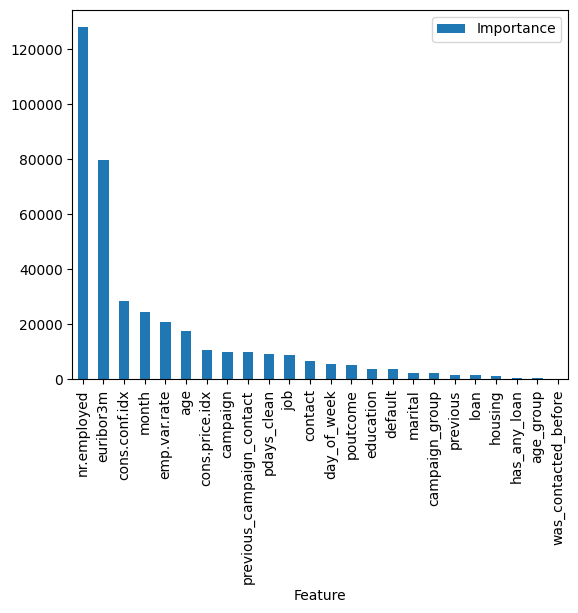

In [49]:
feature_importance_df.set_index('Feature').plot.bar();

Найвищу важливість отримали nr.employed, euribor3m, cons.conf.idx, month, emp.var.rate, age, cons.price.idx, campaign.
Частково такий розподіл є логічним, оскільки модель спирається як на макроекономічні фактори, так і на поведінкові характеристики кампанії.

Водночас цей підхід не показує напрям впливу ознак і може бути зміщеним для корельованих змінних, тому для більш глибокої інтерпретації додатково викоритаємо SHAP.

SHAP оцінює безпосередній внесок кожної ознаки у прогноз моделі.

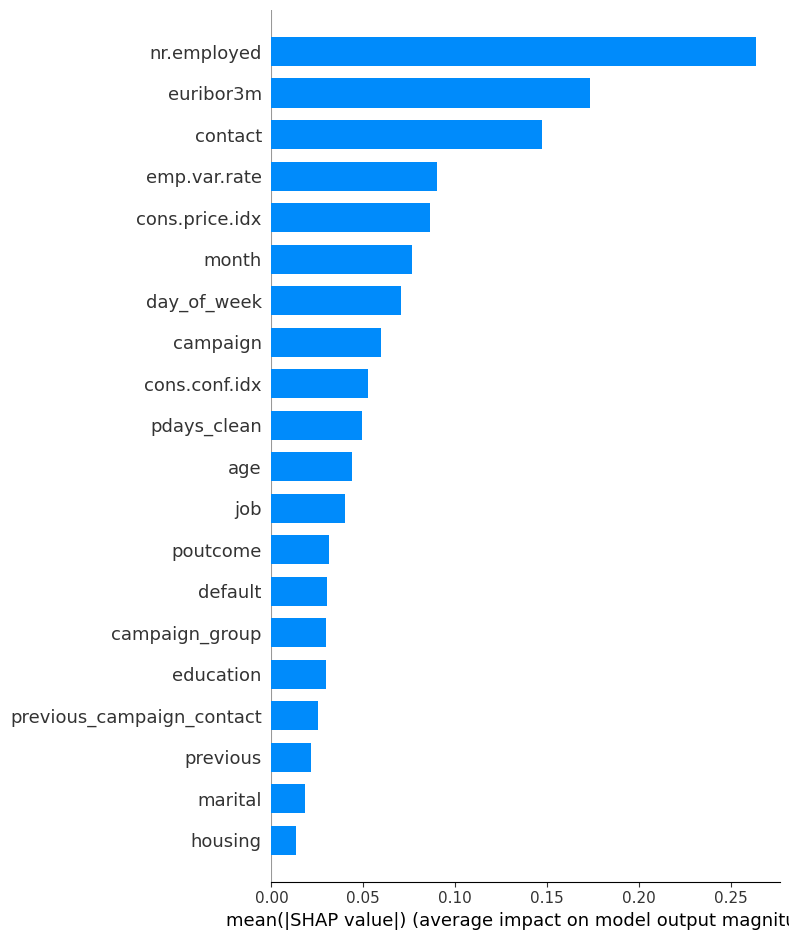

In [50]:
shap_value = shap.TreeExplainer(search.best_estimator_).shap_values(X_test_lgb)
shap.summary_plot(shap_value, X_test_lgb, plot_type="bar");

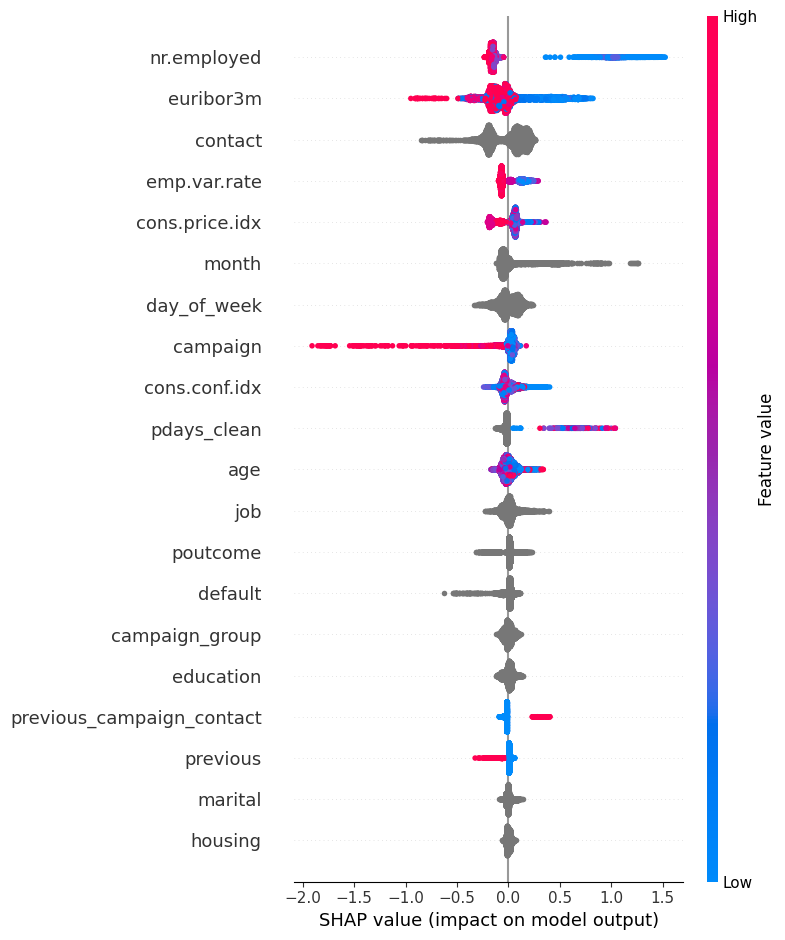

In [51]:
shap.summary_plot(shap_value, X_test_lgb);

###Макроекономічні показники (nr.employed, euribor3m, emp.var.rate)
Ці змінні відображають стан економіки:


процентні ставки (euribor3m)


рівень зайнятості (nr.employed)


економічні коливання (emp.var.rate)


 Нижчі значення цих показників асоціюються з вищою ймовірністю позитивного прогнозу. Імовірно, модель уловлює загальний макроекономічний режим, а не вплив кожної змінної окремо, оскільки ці ознаки є взаємопов’язаними.


###Канал контакту (contact)

Для ознаки contact EDA аналіз показав вищу ймовірність позитивного прогнозу у випадках, коли контакт відбувався через cellular, а не через telephone. Це також ми бачимо аналізі Shap. Також виглядає логічно, оскільки мобільний контакт, ймовірно, є більш актуальним каналом комунікації.


###Час контакту (month, day_of_week)
Незважаючи на те, що модель визначає month як важливу ознаку, детальний аналіз показує, що це може бути пов’язано не стільки з поведінкою клієнтів, скільки зі стратегією проведення маркетингових кампаній.

Зокрема:
розподіл контактів по місяцях є нерівномірним на графіках в EDA аналізі(наприклад, значна кількість контактів у травні)
це може впливати на модель через дисбаланс даних, а не через реальну зміну конверсії.

Щодо day_of_week, його вплив виглядає мінімальним, оскільки розподіл цільової змінної є досить рівномірним для різних днів тижня.
Таким чином, важливість часових ознак слід інтерпретувати обережно, оскільки вони можуть відображати особливості збору даних, а не причинно-наслідкові зв’язки.

###Соціально-демографічні характеристики (age, job)

Мають помірний вплив. Їх інтерпретація менш однозначна, однак можна припустити, що вони частково відображають відмінності у доході, фінансовій поведінці та доступності клієнтів для маркетингових кампаній.

###Аналіз помилок

In [52]:
df_errors = X_test_lgb.copy()
df_errors["y_true"] = y_test.values
df_errors["y_pred"] = y_pred_search_test
df_errors["y_proba"] = y_proba_search_test

In [53]:
# False Positive (модель сказала YES, але насправді NO)
fp = df_errors[(df_errors["y_true"] == 0) & (df_errors["y_pred"] == 1)]

# False Negative (модель сказала NO, але насправді YES)
fn = df_errors[(df_errors["y_true"] == 1) & (df_errors["y_pred"] == 0)]

In [54]:
df_errors.groupby("y_true").mean(numeric_only=True)

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,previous_campaign_contact,pdays_clean,has_any_loan,y_pred,y_proba
y_true,,,,,,,,,,,,,,
0,39.869083,2.702462,0.131053,0.256389,93.602409,-40.520178,3.824220,5176.623912,0.113817,0.013133,6.479167,0.587551,0.119562,0.338473
1,40.961207,2.061422,0.453664,-1.275647,93.339559,-39.908836,2.073832,5093.800862,0.308190,0.187500,5.672414,0.619612,0.639009,0.643190


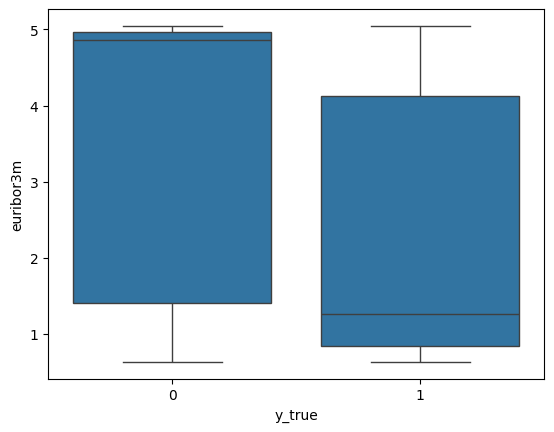

In [55]:
sns.boxplot(data=df_errors, x="y_true", y="euribor3m");

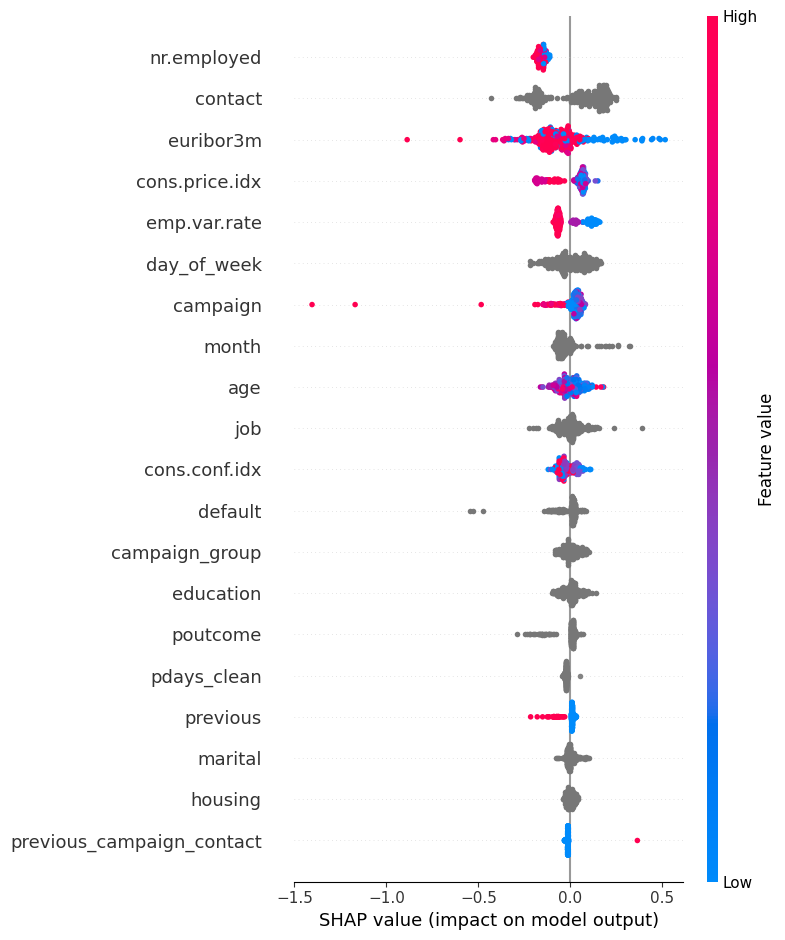

In [56]:
X_fn = fn[X_test_lgb.columns]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_fn)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_fn)

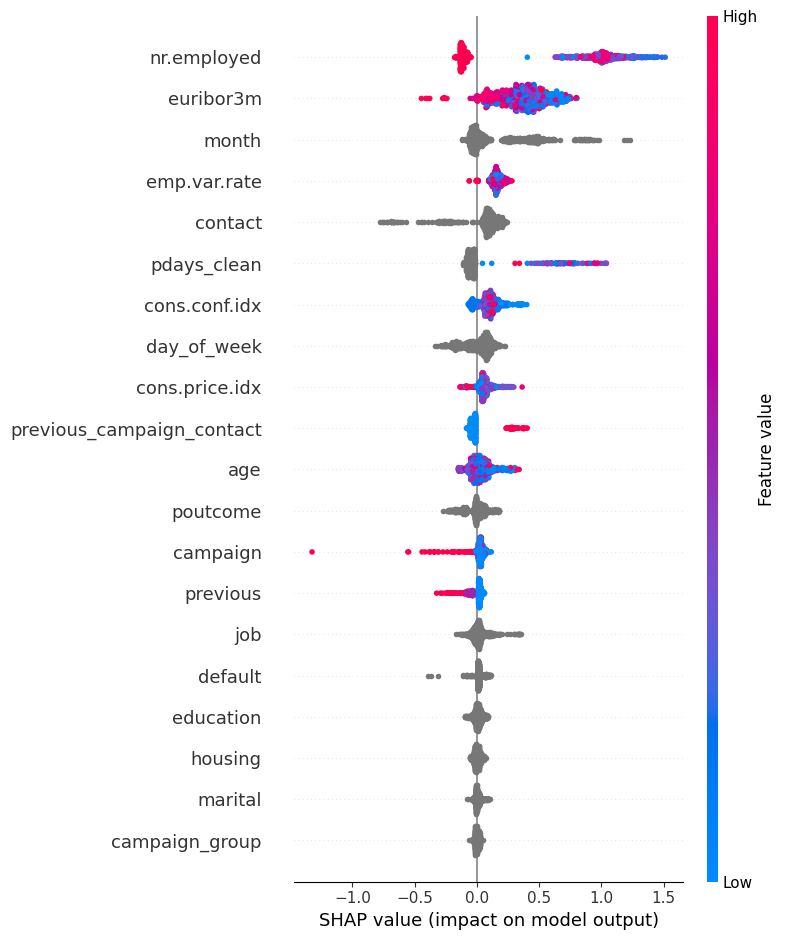

In [57]:
X_fp = fp[X_test_lgb.columns]
shap_values = explainer.shap_values(X_fp)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_fp)

Аналіз помилок показав, що модель має труднощі в ситуаціях, де ознаки дають суперечливі сигнали. Вона схильна переоцінювати макроекономічні фактори та недооцінювати поведінкові характеристики клієнтів, що призводить як до пропуску потенційних клієнтів (False Negative), так і до хибнопозитивних прогнозів (False Positive).

модель переоцінює макроекономічні змінні (nr.employed, euribor3m) → дає FP
модель недооцінює поведінкові фактори (contact) → дає FN
модель занадто сильно штрафує campaign → пропускає хороших клієнтів (FN)
ознака month створює bias (ефект кампаній, а не поведінки клієнта)
є ситуації з конфліктом сигналів, де модель “обирає не той бік”

Для покращення її якості:
По-перше, доцільно оптимізувати поріг класифікації (threshold), оскільки стандартне значення 0.5 може призводити до збільшення кількості помилок типу False Negative. Зниження порогу дозволить підвищити здатність моделі виявляти потенційних клієнтів.

По-друге, варто вдосконалити етап feature engineering. Зокрема, модель може недостатньо ефективно використовувати інформацію про канал контакту (contact), тому доцільно розглянути створення додаткових ознак або взаємодій, які краще відображають вплив мобільного контакту (cellular) на результат.

По-третє, аналіз показав, що ознака campaign має надмірно сильний негативний вплив на прогноз. У зв’язку з цим доцільно трансформувати цю змінну (наприклад, за допомогою логарифмування або бінування), щоб зменшити її диспропорційний вплив на модель.

Крім того, часові ознаки (month, day_of_week) можуть створювати шум і відображати особливості проведення маркетингових кампаній, а не реальну поведінку клієнтів. Тому доцільно розглянути їх видалення або трансформацію перед навчанням моделі.

Таким чином, покращення моделі можливе за рахунок оптимізації порогу класифікації, вдосконалення ознак та зменшення впливу факторів, що створюють зміщення.
